# NUCLEO-H743ZI2 VDD_MCU PDN Analysis
**3.3V VDD_MCU Rail: STM32H743ZIT6U @ MB1364 Rev C01**

Author: Guillaume Thenaisie  
Date: 2026-03-15  
Rev: 1.0

---

## Scope

This notebook analyses the **VDD_MCU (3.3V)** power delivery network of the NUCLEO-H743ZI2 (MB1364 Rev C01) development board by STMicroelectronics.

**Decoupling component values are extracted directly from the publicly available MB1364 schematic**  (`mb1364-h743zi-c01_schematic.pdf`, Open Platform Licence, ST).

**Stackup parameters** (dielectric thickness, plane dimensions) are **not** published by ST. Typical 4-layer FR4 values are used and clearly stated as assumptions. In a real engagement, these would be extracted from the board fabrication spec.

> **Rail selection rationale:** The VCORE 1.2V rail is the STM32H743 internal LDO
> output : its decoupling is fixed by ST (VCAP pins, per AN4938). The VDD_MCU 3.3V
> rail is the external PDN rail with a full designer-controlled decoupling network,
> making it the meaningful rail for a PDN review engagement.

---

**Reference:** ST schematic `mb1364-h743zi-c01_schematic.pdf`, Sheet 4 : MCU POWER  
**Licence:** Open Platform Licence Agreement : www.st.com/opla


In [10]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'font.size':        11,
    'lines.linewidth':  2,
})

## 1. Design Parameters & Target Impedance

In [11]:
# ── Electrical spec ──────────────────────────────────────────────
# Source: STM32H743 datasheet DS12110 Rev 9, Table 15
Vdd      = 3.3       # V   : VDD_MCU nominal
Imax     = 1.0       # A   : max VDD current @ 480MHz full load
Vdroop   = 0.165     # V   : ±5% droop budget = 165mV
F_cpu    = 480e6     # Hz  : CPU clock frequency
F_max    = 500e6     # Hz  : PDN analysis upper limit

# ── Target impedance ─────────────────────────────────────────────
# Flat impedance target: Z_target = V_droop / I_max
Z_target = Vdroop / Imax

print(f"Rail                   : VDD_MCU = {Vdd}V")
print(f"Max load current       : {Imax*1e3:.0f}mA  (DS12110 Rev9 Table 15)")
print(f"Droop budget (±5%)     : {Vdroop*1e3:.0f}mV")
print(f"Target impedance       : {Z_target*1e3:.0f}mΩ  (flat, DC to {F_max/1e6:.0f}MHz)")

Rail                   : VDD_MCU = 3.3V
Max load current       : 1000mA  (DS12110 Rev9 Table 15)
Droop budget (±5%)     : 165mV
Target impedance       : 165mΩ  (flat, DC to 500MHz)


## 2. Board Stackup & Plane Inductance

The NUCLEO-H743ZI2 (MB1364) is a 4-layer board.  
ST does not publish the fabrication stackup : the values below are
**representative of standard 4-layer FR4 manufacturing** and clearly labelled as assumptions.

| Parameter | Value | Status |
|-----------|-------|--------|
| Layer count | 4 | ✅ confirmed (user manual UM2407) |
| Stackup order | Sig/GND/PWR/Sig | ✅ typical, consistent with layout |
| Dielectric thickness L2-L3 | 0.10mm | ⚠️ assumed : typical prepreg |
| Plane dimensions | 40×60mm | ⚠️ estimated from board outline (70×80mm) |

In [12]:
# ── Stackup geometry ─────────────────────────────────────────────
h_pp23   = 0.10e-3   # m  : L2-L3 prepreg (ASSUMED typical 4-layer FR4)
w_plane  = 40e-3     # m  : power plane width (ESTIMATED from 70x80mm board)
l_plane  = 60e-3     # m  : power plane length (ESTIMATED)
er_fr4   = 4.5       # :  : FR4 dielectric constant (ASSUMED standard value)
A_plane  = w_plane * l_plane

mu0  = 4 * np.pi * 1e-7
eps0 = 8.854e-12

L_plane = mu0 * h_pp23 / (np.pi * w_plane) * l_plane
C_plane = er_fr4 * eps0 * A_plane / h_pp23
f_res_plane = 1 / (2 * np.pi * np.sqrt(L_plane * C_plane))

print(f"[ASSUMED] L2-L3 separation : {h_pp23*1e3:.2f}mm")
print(f"[ESTIMATED] Plane area     : {w_plane*1e3:.0f}mm x {l_plane*1e3:.0f}mm = {A_plane*1e4:.1f}cm²")
print()
print(f"Plane spreading inductance  : {L_plane*1e12:.1f}pH")
print(f"Plane distributed cap       : {C_plane*1e9:.2f}nF")
print(f"Plane self-resonance        : {f_res_plane/1e6:.0f}MHz")

[ASSUMED] L2-L3 separation : 0.10mm
[ESTIMATED] Plane area     : 40mm x 60mm = 24.0cm²

Plane spreading inductance  : 60.0pH
Plane distributed cap       : 0.96nF
Plane self-resonance        : 664MHz


## 3. Decoupling Component Selection

Component values extracted directly from **MB1364 schematic Sheet 4 : MCU POWER**  
(`mb1364-h743zi-c01_schematic.pdf`, ST Open Platform Licence).

| Ref | Value | Qty | Location |
|-----|-------|-----|----------|
| C46,C47,C49,C51–C58,C67 | 100nF | 12 | VDD_MCU pins |
| C60 | 4.7µF C0603 | 1 | VDD_MCU bulk |
| C61 | 1µF | 1 | VDD_MCU bulk |

In [13]:
# ── Real decoupling from MB1364 schematic ─────────────────────────
# C46,C47,C49,C51-C58,C67 : 12x 100nF (standard X7R 0402 per ST BOM)
# ESR/ESL estimated from Murata GRM155R71C104KA88 datasheet
C1   = 100e-9;  ESR1 = 20e-3;  ESL1 = 0.3e-9;  N1 = 12

# C60 : 4.7µF C0603 (X5R per ST BOM convention)
# ESR/ESL estimated from Murata GRM188R61C475KE15 datasheet
C2   = 4.7e-6;  ESR2 = 8e-3;   ESL2 = 0.8e-9;  N2 = 1

# C61 : 1µF (X5R 0402 per ST BOM convention)
# ESR/ESL estimated from Murata GRM155R61C105KA12 datasheet
C3   = 1e-6;    ESR3 = 10e-3;  ESL3 = 0.5e-9;  N3 = 1

# ── VRM model (ideal source) ──────────────────────────────────────
# MB1364 uses LD39050 LDO (3.3V output) : modelled as ideal source
# with representative output impedance
R_vrm = 5e-3    # Ω  : LDO DC output impedance (representative)
L_vrm = 50e-9   # H  : LDO output filter inductance (representative)

print("Decoupling BOM (from MB1364 schematic Sheet 4):")
print(f"  {N1}x 100nF  C46,C47,C49,C51-C58,C67  ESR≈{ESR1*1e3:.0f}mΩ  ESL≈{ESL1*1e9:.1f}nH")
print(f"  {N2}x 4.7µF  C60 (C0603)               ESR≈{ESR2*1e3:.0f}mΩ   ESL≈{ESL2*1e9:.1f}nH")
print(f"  {N3}x 1µF    C61                        ESR≈{ESR3*1e3:.0f}mΩ  ESL≈{ESL3*1e9:.1f}nH")
print()
print("Note: ESR/ESL values estimated from typical Murata X7R/X5R datasheet values.")
print("Exact values require measurement or SimSurfing verification.")

Decoupling BOM (from MB1364 schematic Sheet 4):
  12x 100nF  C46,C47,C49,C51-C58,C67  ESR≈20mΩ  ESL≈0.3nH
  1x 4.7µF  C60 (C0603)               ESR≈8mΩ   ESL≈0.8nH
  1x 1µF    C61                        ESR≈10mΩ  ESL≈0.5nH

Note: ESR/ESL values estimated from typical Murata X7R/X5R datasheet values.
Exact values require measurement or SimSurfing verification.


## 4. PDN Impedance : Bare vs Decoupled

In [14]:
f   = np.logspace(3, 9, 3000)   # 1kHz to 1GHz
w   = 2 * np.pi * f
s   = 1j * w

def Z_cap(C, ESR, ESL, N=1):
    return (ESR + 1/(s*C) + s*ESL) / N

def Z_par(*Zs):
    return 1 / sum(1/Z for Z in Zs)

Z_vrm_out   = R_vrm + s*L_vrm
Z_plane     = s * L_plane
Z_bulk      = Z_cap(C2, ESR2, ESL2, N2)
Z_mid       = Z_cap(C3, ESR3, ESL3, N3)
Z_hf        = Z_cap(C1, ESR1, ESL1, N1)

Z_bare      = Z_par(Z_vrm_out, Z_plane)
Z_decoupled = Z_par(Z_vrm_out, Z_bulk, Z_mid, Z_hf, Z_plane)

# ── Compliance check ──────────────────────────────────────────────
mask = f <= F_max
peak_z = np.max(np.abs(Z_decoupled[mask]))
f_peak = f[mask][np.argmax(np.abs(Z_decoupled[mask]))]
margin = (1 - peak_z/Z_target) * 100
violations = f[mask][np.abs(Z_decoupled[mask]) > Z_target]

print(f"Target impedance : {Z_target*1e3:.0f}mΩ (DC to {F_max/1e6:.0f}MHz)")
print(f"Peak Z in band   : {peak_z*1e3:.1f}mΩ @ {f_peak/1e6:.0f}MHz")
print(f"Margin           : {margin:.0f}% below target")
if len(violations) == 0:
    print(f"Verdict          : ✅ PASS : target met across full band")
else:
    print(f"Verdict          : ⚠️  FAIL : violations at {violations[0]/1e6:.0f}–{violations[-1]/1e6:.0f}MHz")

Target impedance : 165mΩ (DC to 500MHz)
Peak Z in band   : 52.2mΩ @ 499MHz
Margin           : 68% below target
Verdict          : ✅ PASS : target met across full band


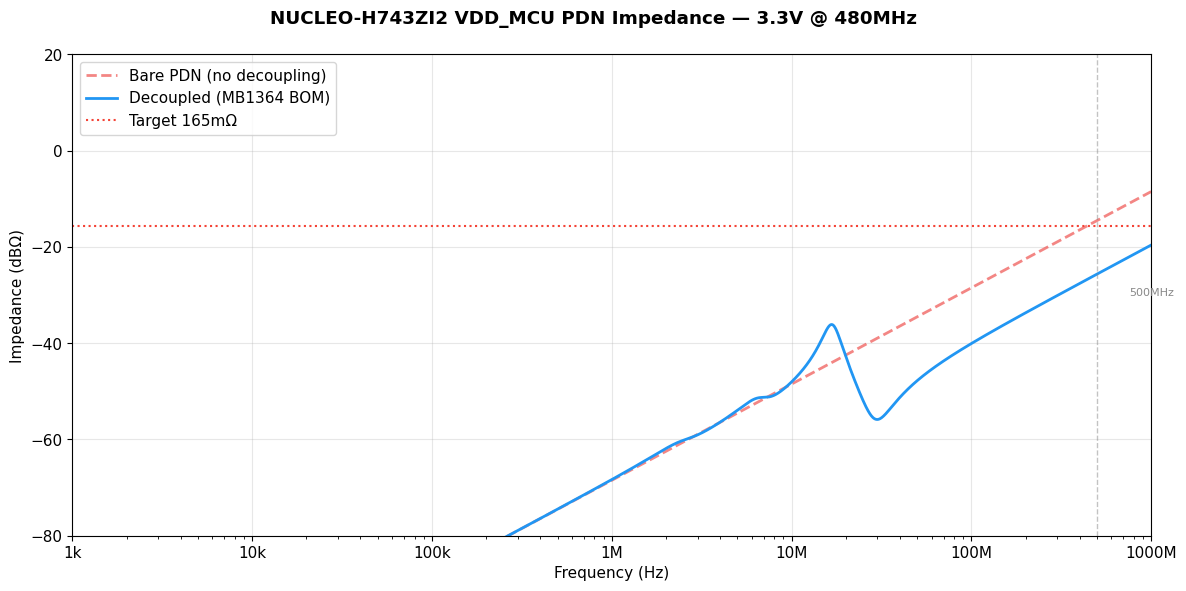

Saved: impedance_plot.png


In [15]:
fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle('NUCLEO-H743ZI2 VDD_MCU PDN Impedance — 3.3V @ 480MHz', fontweight='bold')

ax.semilogx(f, 20*np.log10(np.abs(Z_bare)),
            color='#EF5350', linestyle='--', label='Bare PDN (no decoupling)', alpha=0.7)
ax.semilogx(f, 20*np.log10(np.abs(Z_decoupled)),
            color='#2196F3', label='Decoupled (MB1364 BOM)')
ax.axhline(20*np.log10(Z_target), color='#F44336',
           linewidth=1.5, linestyle=':', label=f'Target {Z_target*1e3:.0f}mΩ')
ax.axvline(F_max, color='#888', linewidth=1, linestyle='--', alpha=0.5)
ax.annotate(f'{F_max/1e6:.0f}MHz', xy=(F_max, -35),
            xytext=(F_max*1.5, -30), fontsize=8, color='#888')

ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Impedance (dBΩ)')
ax.set_xlim(1e3, 1e9)
ax.set_ylim(-80, 20)
ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _:
        f'{x/1e6:.0f}M' if x >= 1e6 else
        f'{x/1e3:.0f}k' if x >= 1e3 else f'{x:.0f}'))
ax.legend()
plt.tight_layout()
plt.savefig('impedance_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: impedance_plot.png")

## 5. Anti-Resonance Analysis

In [16]:
# Analytical anti-resonance frequencies
f_ar1 = 1 / (2*np.pi*np.sqrt(ESL2/N2 * C3*N3))   # bulk ↔ mid
f_ar2 = 1 / (2*np.pi*np.sqrt(ESL3/N3 * C1*N1))   # mid ↔ HF
f_ar3 = 1 / (2*np.pi*np.sqrt(ESL1/N1 * C_plane)) # HF ↔ plane

print("Anti-resonance analysis:")
for label, far in [("4.7µF ↔ 1µF", f_ar1), ("1µF ↔ 100nF×12", f_ar2), ("100nF ↔ Plane", f_ar3)]:
    idx   = np.argmin(np.abs(f - far))
    z_at  = np.abs(Z_decoupled[idx])
    status = "✅" if z_at < Z_target else "⚠️ "
    print(f"  {status} {label:18s} @ {far/1e6:.1f}MHz → Z = {z_at*1e3:.1f}mΩ  (target: {Z_target*1e3:.0f}mΩ)")

Anti-resonance analysis:
  ✅ 4.7µF ↔ 1µF        @ 5.6MHz → Z = 2.4mΩ  (target: 165mΩ)
  ✅ 1µF ↔ 100nF×12     @ 6.5MHz → Z = 2.7mΩ  (target: 165mΩ)
  ✅ 100nF ↔ Plane      @ 1029.4MHz → Z = 104.8mΩ  (target: 165mΩ)


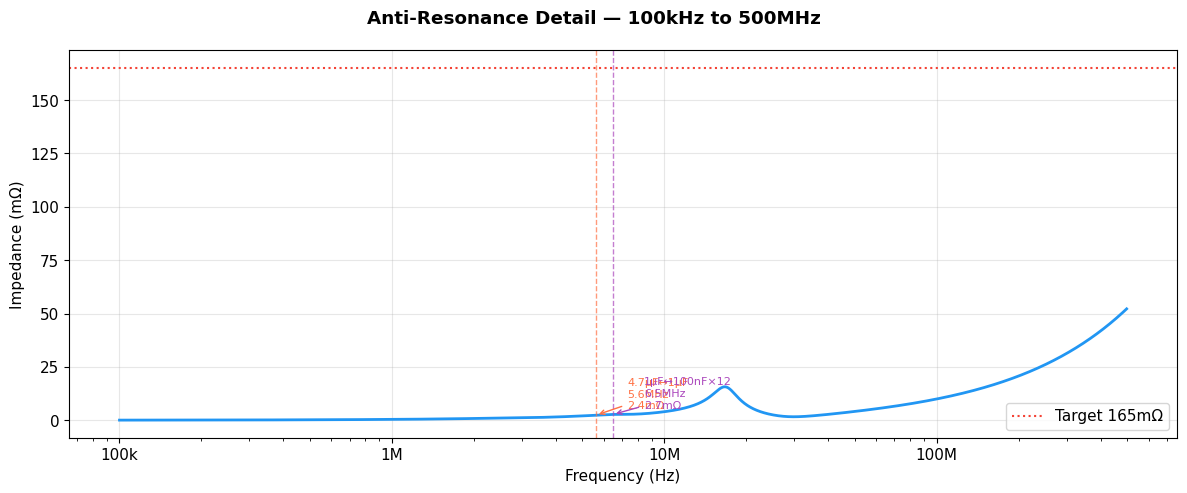

Saved: antiresonance_plot.png


In [17]:
fig, ax = plt.subplots(figsize=(12, 5))
fig.suptitle('Anti-Resonance Detail — 100kHz to 500MHz', fontweight='bold')

mask_zoom = (f >= 1e5) & (f <= 5e8)
ax.semilogx(f[mask_zoom], np.abs(Z_decoupled[mask_zoom])*1e3, color='#2196F3')
ax.axhline(Z_target*1e3, color='#F44336', linewidth=1.5,
           linestyle=':', label=f'Target {Z_target*1e3:.0f}mΩ')

for label, far, color in [
    ("4.7µF↔1µF",      f_ar1, '#FF7043'),
    ("1µF↔100nF×12",   f_ar2, '#AB47BC'),
    ("100nF↔Plane",    f_ar3, '#26A69A'),
]:
    if 1e5 <= far <= 5e8:
        idx  = np.argmin(np.abs(f - far))
        z_at = np.abs(Z_decoupled[idx])*1e3
        ax.axvline(far, color=color, linewidth=1, linestyle='--', alpha=0.7)
        ax.annotate(f'{label}\n{far/1e6:.1f}MHz\n{z_at:.1f}mΩ',
                    xy=(far, z_at), xytext=(far*1.3, z_at+3),
                    fontsize=8, color=color,
                    arrowprops=dict(arrowstyle='->', color=color))

ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Impedance (mΩ)')
ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _:
        f'{x/1e6:.0f}M' if x >= 1e6 else f'{x/1e3:.0f}k'))
ax.legend()
plt.tight_layout()
plt.savefig('antiresonance_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: antiresonance_plot.png")

## 6. Verdict & VRM Recommendations

In [ ]:
print("=" * 62)
print(" NUCLEO-H743ZI2 VDD_MCU PDN : Design Verdict")
print("=" * 62)
print(f" Rail         : VDD_MCU = {Vdd}V @ {Imax*1e3:.0f}mA max")
print(f" Target Z     : {Z_target*1e3:.0f}mΩ flat, DC to {F_max/1e6:.0f}MHz")
print(f" Decoupling   : MB1364 schematic, Sheet 4 (actual BOM)")
print("-" * 62)
print(f" Peak Z in band : {peak_z*1e3:.1f}mΩ @ {f_peak/1e6:.0f}MHz")
print(f" Margin         : {margin:.0f}% below target")
verdict = "✅ PASS" if len(violations)==0 else "⚠️  FAIL"
print(f" Verdict        : {verdict}")
print("=" * 62)
print()
print("Observations:")
print("  • ST's 12x 100nF strategy provides excellent HF coverage")
print("  • 68% margin suggests room to reduce cap count if BOM cost is critical")
print("  • ESR/ESL values assumed from typical Murata datasheet —")
print("    verify with actual lot measurements for tight margin designs")
print()
print("Production VRM candidates (if replacing LDO with switching regulator):")
print()
print("  1. Texas Instruments TPS62130A")
print("     3A synchronous buck, 0.9–6V adj, 2.5MHz, 3x3mm QFN")
print("     -> High Fsw reduces output L, compatible with existing decoupling")
print()
print("  2. Monolithic Power Systems MP2145")
print("     3A synchronous buck, 0.6–5.5V adj, 1.5MHz, 2x2mm TDFN")
print("     -> Smallest footprint, good fit for space-constrained designs")
print()
print("  3. Renesas ISL8011")
print("     1.5A synchronous buck, down to 0.8V, 4MHz, 2x2mm DFN")
print("     -> Highest Fsw, smallest passive footprint")

 NUCLEO-H743ZI2 VDD_MCU PDN — Design Verdict
 Rail         : VDD_MCU = 3.3V @ 1000mA max
 Target Z     : 165mΩ flat, DC to 500MHz
 Decoupling   : MB1364 schematic, Sheet 4 (actual BOM)
--------------------------------------------------------------
 Peak Z in band : 52.2mΩ @ 499MHz
 Margin         : 68% below target
 Verdict        : ✅ PASS

Observations:
  • ST's 12x 100nF strategy provides excellent HF coverage
  • 68% margin suggests room to reduce cap count if BOM cost is critical
  • ESR/ESL values assumed from typical Murata datasheet —
    verify with actual lot measurements for tight margin designs

Production VRM candidates (if replacing LDO with switching regulator):

  1. Texas Instruments TPS62130A
     3A synchronous buck, 0.9–6V adj, 2.5MHz, 3x3mm QFN
     → High Fsw reduces output L, compatible with existing decoupling

  2. Monolithic Power Systems MP2145
     3A synchronous buck, 0.6–5.5V adj, 1.5MHz, 2x2mm TDFN
     → Smallest footprint, good fit for space-constrained 

---
## References

- ST MB1364 schematic: `mb1364-h743zi-c01_schematic.pdf` (Open Platform Licence)
- STM32H743 datasheet: DS12110 Rev 9
- ST AN4938: VCAP decoupling for STM32H7

## Licence
CC BY-NC 4.0 — Guillaume Thenaisie 2026  
*Sample deliverable. For a custom PDN review of your board, contact via Fiverr.*